In questo codice si valida la high fidelity solution, quindi verrà fissata una soluzione esatta (in particolare quella del laib su navier stocks)
e verrà controllato che, variando il valore del parametro (ci atteniamo al dominio dato):
- Newton converge (quadraticamente)
- l'errore scala con l'ordine atteso dal metodo riducendo la dimensione della mesh

Per questo motivo i parametri saranno fissati ma sarà considerata una soluzione esatta e verrà calcolato il forcing term (costante) in modo che tale che la soluzione fissata sia soluzione del problema variazionale. 

In [1]:
import numpy as np
import argparse
import os.path
import scipy.sparse
import vtk
from pypolydim import polydim, gedim
from pypolydim.export_vtk_utilities import ExportVTKUtilities
from pypolydim.assembler_utilities import assembler_utilities
import matplotlib.pyplot as plt

import sys
sys.path.insert(1, '../')
import other_utilities as other_ut

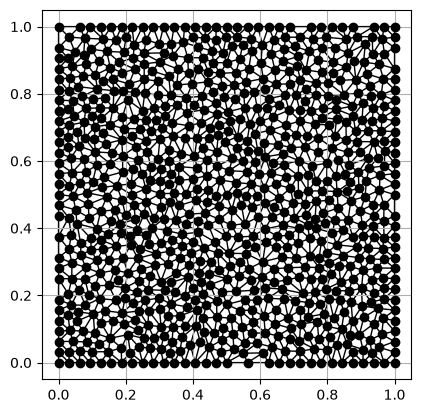

In [2]:
geometry_utilities_config = gedim.GeometryUtilitiesConfig()
geometry_utilities_config.tolerance1_d = 1.0e-6
geometry_utilities_config.tolerance2_d = 1.0e-12
geometry_utilities = gedim.GeometryUtilities(geometry_utilities_config)
mesh_utilities = gedim.MeshUtilities()
vtk_utilities = ExportVTKUtilities()

## EXPORT

# Export folder
export_file_path = "./Export/Test_1"
if not os.path.exists(export_file_path):
    os.makedirs(export_file_path)

# Mesh file path
export_mesh_path = export_file_path + "/Mesh"
if not os.path.exists(export_mesh_path):
    os.makedirs(export_mesh_path)

# Solution file path
export_solution_path = export_file_path + "/Solution"
if not os.path.exists(export_solution_path):
    os.makedirs(export_solution_path)

## DISCRETIZATION
pde_domain = polydim.pde_tools.mesh.pde_mesh_utilities.PDE_Domain_2D()
pde_domain.vertices = np.array([[0.0, 1.0, 1.0, 0.0],
                                [0.0, 0.0, 1.0, 1.0],
                                [0.0, 0.0, 0.0, 0.0]])
pde_domain.shape_type = polydim.pde_tools.mesh.pde_mesh_utilities.PDE_Domain_2D.Domain_Shape_Types.parallelogram
pde_domain.area = 1.0
mesh_type = polydim.pde_tools.mesh.pde_mesh_utilities.MeshGenerator_Types_2D.triangular
method_type = polydim.pde_tools.local_space_pcc_2_d.MethodTypes.fem_pcc
mesh_size = 0.001   # mesh_size è il parametro h — cioè la dimensione caratteristica degli elementi della mesh. 
# Indica la lunghezza massima (o tipica) dello spigolo di un triangolo. Errore scala con tale taglia: ‖u − u_h‖ ≤ C · h^k

mesh_data = gedim.MeshMatrices()
mesh = gedim.MeshMatricesDAO(mesh_data)

polydim.pde_tools.mesh.pde_mesh_utilities.create_mesh_2_d(geometry_utilities,
                                                          mesh_utilities,
                                                          mesh_type,
                                                          pde_domain,
                                                          mesh_size,
                                                          mesh)
mesh_geometric_data = polydim.pde_tools.mesh.pde_mesh_utilities.compute_mesh_2_d_geometry_data(geometry_utilities, mesh_utilities, mesh)
vtk_utilities.export_mesh(export_mesh_path, mesh)
other_ut.plot_mesh(mesh)

## BOUNDARY CONDITIONS
info_internal = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.none)
info_internal.marker = 0

info_dirichlet = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.strong)
info_dirichlet.marker = 1

info_neumann_none = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.none)
info_neumann_none.marker = 0

pressure_boundary_info = {
    0: info_internal,
    1: info_dirichlet,
    2: info_neumann_none,
    3: info_neumann_none,
    4: info_neumann_none,
    5: info_neumann_none,
    6: info_neumann_none,
    7: info_neumann_none,
    8: info_neumann_none
}

speed_boundary_info = {
    0: info_internal,
    1: info_dirichlet,
    2: info_dirichlet,
    3: info_dirichlet,
    4: info_dirichlet,
    5: info_dirichlet,
    6: info_dirichlet,
    7: info_dirichlet,
    8: info_dirichlet
}


## BASIS AND DOFS (FEM)

mesh_connectivity_data = polydim.pde_tools.mesh.MeshMatricesDAO_mesh_connectivity_data(mesh)

pressure_reference_element_data = polydim.pde_tools.local_space_pcc_2_d.create_reference_element(method_type, 
                                                                                              1)
speed_reference_element_data = polydim.pde_tools.local_space_pcc_2_d.create_reference_element(method_type, 
                                                                                             2)

dof_manager = polydim.pde_tools.do_fs.DOFsManager()

pressure_mesh_dofs_info = polydim.pde_tools.local_space_pcc_2_d.set_mesh_do_fs_info(pressure_reference_element_data, 
                                                                                    mesh, 
                                                                                    pressure_boundary_info)
pressure_dofs_data = dof_manager.create_do_fs_2_d(pressure_mesh_dofs_info, 
                                                  mesh_connectivity_data)

speed_mesh_dofs_info = polydim.pde_tools.local_space_pcc_2_d.set_mesh_do_fs_info(speed_reference_element_data, 
                                                                                 mesh, 
                                                                                 speed_boundary_info)
speed_dofs_data = dof_manager.create_do_fs_2_d(speed_mesh_dofs_info, 
                                               mesh_connectivity_data)
pressure_n_dofs = pressure_dofs_data.number_do_fs
pressure_n_strongs = pressure_dofs_data.number_strongs
speed_n_dofs = speed_dofs_data.number_do_fs
speed_n_strongs = speed_dofs_data.number_strongs
tot_dofs = 2 * speed_n_dofs + pressure_n_dofs
tot_strongs = 2 * speed_n_strongs + pressure_n_strongs
# I DOFs (Degrees of Freedom) sono i valori incogniti che il metodo FEM deve calcolare — cioè i valori della soluzione nei punti "liberi" della mesh.
# In FEM non cerchi la funzione continua u(x) direttamente — la approssimi come combinazione lineare di funzioni base. I DOFs sono i coefficienti uᵢ u_h(x) = Σᵢ uᵢ · φᵢ(x)

In [3]:
## EXACT SOLUTIONS
# SOLUZIONE esatta presa da NS

def pressure_exact(x, y, z):
    return np.pi * np.pi * np.sin(2.0 * np.pi * x) * np.cos(2.0 * np.pi * y)

def pressure_exact_gradient(x, y, z):
    return np.array([\
        +2.0 * np.pi * np.pi * np.pi * np.cos(2.0 * np.pi * x) * np.cos(2.0 * np.pi * y),\
        -2.0 * np.pi * np.pi * np.pi * np.sin(2.0 * np.pi * x) * np.sin(2.0 * np.pi * y),\
        0.0])

def speed_x_exact(x, y, z):
    return +0.5 * np.sin(2.0 * np.pi * x) * np.sin(2.0 * np.pi * x) * np.sin(2.0 * np.pi * y) * np.cos(2.0 * np.pi * y)
def speed_y_exact(x, y, z):
    return -0.5 * np.sin(2.0 * np.pi * y) * np.sin(2.0 * np.pi * y) * np.sin(2.0 * np.pi * x) * np.cos(2.0 * np.pi * x)

def speed_x_exact_laplacian(x, y, z):
    return +2.0 * np.pi * np.pi * np.sin(4.0 * np.pi * y) * (2.0 * np.cos(4.0 * np.pi * x) - 1.0)
def speed_y_exact_laplacian(x, y, z):
    return -2.0 * np.pi * np.pi * np.sin(4.0 * np.pi * x) * (2.0 * np.cos(4.0 * np.pi * y) - 1.0)

def pressure_strong_function(marker, x, y, z):  
    return pressure_exact(x, y, z)

p_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       pressure_mesh_dofs_info,
                                                                       pressure_dofs_data,
                                                                       pressure_reference_element_data,
                                                                       pressure_strong_function)
def speed_x_strong_function(marker, x, y, z):  
    return speed_x_exact(x, y, z)
def speed_y_strong_function(marker, x, y, z):  
    return speed_y_exact(x, y, z)


u_x_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_mesh_dofs_info,
                                                                       speed_dofs_data,
                                                                       speed_reference_element_data,
                                                                       speed_x_strong_function)
u_y_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_mesh_dofs_info,
                                                                       speed_dofs_data,
                                                                       speed_reference_element_data,
                                                                       speed_y_strong_function)

In [4]:
# Parametri del test di validazione
nu_values   = [0.1, 1.0, 5, 10.0]          # μ₀ ∈ [0.1, 10] come da testo
mesh_sizes  = [0.001,  0.007, 0.025,   0.05,   0.1 ]   # h decrescente per test di convergenza

In [5]:
# loop per testare tutto (è il codice solito ma in una sola cella)

def solve(nu, mesh_size):
    # --- Mesh ---
    mesh_data = gedim.MeshMatrices()
    mesh = gedim.MeshMatricesDAO(mesh_data)
    polydim.pde_tools.mesh.pde_mesh_utilities.create_mesh_2_d(
        geometry_utilities, mesh_utilities, mesh_type, pde_domain, mesh_size, mesh)
    mesh_geometric_data = polydim.pde_tools.mesh.pde_mesh_utilities.compute_mesh_2_d_geometry_data(
        geometry_utilities, mesh_utilities, mesh)
    mesh_connectivity_data = polydim.pde_tools.mesh.MeshMatricesDAO_mesh_connectivity_data(mesh)
 
    # --- DOFs ---
    pressure_reference_element_data = polydim.pde_tools.local_space_pcc_2_d.create_reference_element(method_type, 1)
    speed_reference_element_data    = polydim.pde_tools.local_space_pcc_2_d.create_reference_element(method_type, 2)
    dof_manager = polydim.pde_tools.do_fs.DOFsManager()
 
    pressure_mesh_dofs_info = polydim.pde_tools.local_space_pcc_2_d.set_mesh_do_fs_info(
        pressure_reference_element_data, mesh, pressure_boundary_info)
    pressure_dofs_data = dof_manager.create_do_fs_2_d(pressure_mesh_dofs_info, mesh_connectivity_data)
 
    speed_mesh_dofs_info = polydim.pde_tools.local_space_pcc_2_d.set_mesh_do_fs_info(
        speed_reference_element_data, mesh, speed_boundary_info)
    speed_dofs_data = dof_manager.create_do_fs_2_d(speed_mesh_dofs_info, mesh_connectivity_data)
 
    pressure_n_dofs    = pressure_dofs_data.number_do_fs
    pressure_n_strongs = pressure_dofs_data.number_strongs
    speed_n_dofs       = speed_dofs_data.number_do_fs
    speed_n_strongs    = speed_dofs_data.number_strongs
    tot_dofs           = 2 * speed_n_dofs + pressure_n_dofs
 
    # --- Strong BCs (soluzioni esatte sui bordi) ---
    p_strong   = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(
        geometry_utilities, mesh, mesh_geometric_data,
        pressure_mesh_dofs_info, pressure_dofs_data, pressure_reference_element_data,
        lambda mk, x, y, z: pressure_exact(x, y, z))
    u_x_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(
        geometry_utilities, mesh, mesh_geometric_data,
        speed_mesh_dofs_info, speed_dofs_data, speed_reference_element_data,
        lambda mk, x, y, z: speed_x_exact(x, y, z))
    u_y_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(
        geometry_utilities, mesh, mesh_geometric_data,
        speed_mesh_dofs_info, speed_dofs_data, speed_reference_element_data,
        lambda mk, x, y, z: speed_y_exact(x, y, z))
 
    # --- Forzante (costruito ad hoc affinchè la soluzione scelta sia soluzione) ---
    def f_x_function(x, y, z):
        ux  = speed_x_exact(x, y, z)
        uy  = speed_y_exact(x, y, z)
        dux_dx = 0.5 * np.pi * np.sin(4*np.pi*x) * np.sin(4*np.pi*y)
        dux_dy = np.pi * np.sin(2*np.pi*x)**2 * np.cos(4*np.pi*y)
        return -nu * speed_x_exact_laplacian(x,y,z) + ux*dux_dx + uy*dux_dy + pressure_exact_gradient(x,y,z)[0]
    
    def f_y_function(x, y, z):
        ux  = speed_x_exact(x, y, z)
        uy  = speed_y_exact(x, y, z)
        duy_dx = -np.pi * np.sin(2*np.pi*y)**2 * np.cos(4*np.pi*x)
        duy_dy = -0.5 * np.pi * np.sin(4*np.pi*x) * np.sin(4*np.pi*y)
        return -nu * speed_y_exact_laplacian(x,y,z) + ux*duy_dx + uy*duy_dy + pressure_exact_gradient(x,y,z)[1]
 
    f_vec_x = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(
        geometry_utilities, mesh, mesh_geometric_data,
        speed_dofs_data, speed_reference_element_data, speed_reference_element_data, f_x_function)
    f_vec_y = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(
        geometry_utilities, mesh, mesh_geometric_data,
        speed_dofs_data, speed_reference_element_data, speed_reference_element_data, f_y_function)
    f_S = np.concatenate([f_vec_x, f_vec_y, np.zeros(pressure_n_dofs)])
 
    # --- Operatori lineari ---
    def nu_term(x, y, z): return nu
    def b_x_term(x, y, z): return np.array([1., 0., 0.])
    def b_y_term(x, y, z): return np.array([0., 1., 0.])
 
    A_op = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_diffusion_operator(
        geometry_utilities, mesh, mesh_geometric_data,
        speed_dofs_data, speed_dofs_data,
        speed_reference_element_data, speed_reference_element_data, nu_term)
    J_A_x = other_ut.make_np_sparse(A_op.operator_dofs, [tot_dofs, tot_dofs], [0, 0])
    J_A_y = other_ut.make_np_sparse(A_op.operator_dofs, [tot_dofs, tot_dofs], [speed_n_dofs, speed_n_dofs])
 
    B_x_op = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_advection_operator(
        geometry_utilities, mesh, mesh_geometric_data,
        speed_dofs_data, pressure_dofs_data,
        speed_reference_element_data, pressure_reference_element_data, b_x_term)
    B_y_op = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_advection_operator(
        geometry_utilities, mesh, mesh_geometric_data,
        speed_dofs_data, pressure_dofs_data,
        speed_reference_element_data, pressure_reference_element_data, b_y_term)
 
    J_B_x  = other_ut.make_np_sparse(B_x_op.operator_dofs, [tot_dofs, tot_dofs], [2*speed_n_dofs, 0])
    J_B_y  = other_ut.make_np_sparse(B_y_op.operator_dofs, [tot_dofs, tot_dofs], [2*speed_n_dofs, speed_n_dofs])
    J_BT_x = other_ut.make_np_sparse(B_x_op.operator_dofs, [tot_dofs, tot_dofs], [2*speed_n_dofs, 0], True)
    J_BT_y = other_ut.make_np_sparse(B_y_op.operator_dofs, [tot_dofs, tot_dofs], [2*speed_n_dofs, speed_n_dofs], True)
    J_S = J_A_x + J_A_y - J_B_x - J_B_y - J_BT_x - J_BT_y
 
    # --- Soluzione esatta proiettata (alpha): è la soluzione "vera" nel spazio FEM ---
    # Serve per calcolare l'errore alpha - x_n ad ogni iterazione
    alpha_ux = polydim.pde_tools.assembler_utilities.pcc_2_d.evaluate_function_on_dofs(
        geometry_utilities, mesh, mesh_geometric_data,
        speed_dofs_data, speed_reference_element_data,
        speed_x_exact).function_dofs
    alpha_uy = polydim.pde_tools.assembler_utilities.pcc_2_d.evaluate_function_on_dofs(
        geometry_utilities, mesh, mesh_geometric_data,
        speed_dofs_data, speed_reference_element_data,
        speed_y_exact).function_dofs
    alpha_p = polydim.pde_tools.assembler_utilities.pcc_2_d.evaluate_function_on_dofs(
        geometry_utilities, mesh, mesh_geometric_data,
        pressure_dofs_data, pressure_reference_element_data,
        pressure_exact).function_dofs
    # alpha è il vettore completo della soluzione esatta proiettata
    alpha = np.concatenate([alpha_ux, alpha_uy, alpha_p])
    norma_alpha = np.linalg.norm(alpha)
    
 
    # --- Newton ---
    # Sono le proiezioni questa funzione nello spazio FEM delle soluzioni iniziali (che sono nulle)
    u_x_numeric = np.zeros(speed_n_dofs)
    u_y_numeric = np.zeros(speed_n_dofs)
    p_numeric   = np.zeros(pressure_n_dofs)
    u_k = np.concatenate([u_x_numeric, u_y_numeric, p_numeric])
 
    du_x_strong = np.zeros(speed_n_strongs)
    du_y_strong = np.zeros(speed_n_strongs)
    dp_strong   = np.zeros(pressure_n_strongs)

    last_sol_u = np.zeros(tot_dofs)
 
    errori_newton = []   # errori_newton[k] = ||x* - x_k||_2
    residui_relativi = []   # residui relativi[k] = ||u_k - u_{k-1}|| / ||u_k||
 
    residual_norm, solution_norm = 1.0, 1.0
    
    newton_tol, max_iterations, num_iteration = 1.0e-6, 100, 1
 
    while num_iteration < max_iterations and residual_norm > newton_tol * solution_norm:
        c_op = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_ns_operators(
            geometry_utilities, mesh, mesh_geometric_data,
            speed_dofs_data, speed_reference_element_data,
            u_x_numeric, u_y_numeric, u_x_strong, u_y_strong)
 
        J_C = other_ut.make_np_sparse(c_op.convective_operator.operator_dofs, [tot_dofs, tot_dofs], [0, 0])
        f_C = np.concatenate([c_op.convective_rhs, np.zeros(pressure_n_dofs)])
 
        J_f = f_S - f_C - J_S @ u_k
        du  = scipy.sparse.linalg.spsolve(J_S + J_C, J_f)

        u_k = u_k + du        
 
        u_x_numeric = u_k[:speed_n_dofs]
        u_y_numeric = u_k[speed_n_dofs:2*speed_n_dofs]
        p_numeric   = u_k[2*speed_n_dofs:]
 
        du_x = du[:speed_n_dofs]
        du_y = du[speed_n_dofs:2*speed_n_dofs]
        dp   = du[2*speed_n_dofs:]


        ## NORME ERRORI E RESIDUI

        du_x_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                 mesh,
                                                                                 mesh_geometric_data,
                                                                                 speed_dofs_data,
                                                                                 speed_reference_element_data,
                                                                                 du_x,
                                                                                 du_x_strong)
        du_y_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                     mesh,
                                                                                     mesh_geometric_data,
                                                                                     speed_dofs_data,
                                                                                     speed_reference_element_data,
                                                                                     du_y,
                                                                                     du_y_strong)
        dp_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                     mesh,
                                                                                     mesh_geometric_data,
                                                                                     pressure_dofs_data,
                                                                                     pressure_reference_element_data,
                                                                                     dp,
                                                                                     dp_strong)
        u_x_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                    mesh,
                                                                                    mesh_geometric_data,
                                                                                    speed_dofs_data,
                                                                                    speed_reference_element_data,
                                                                                    u_x_numeric,
                                                                                    u_x_strong,
                                                                                    speed_x_exact)
        u_y_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                    mesh,
                                                                                    mesh_geometric_data,
                                                                                    speed_dofs_data,
                                                                                    speed_reference_element_data,
                                                                                    u_y_numeric,
                                                                                    u_y_strong,
                                                                                    speed_y_exact)
        p_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                    mesh,
                                                                                    mesh_geometric_data,
                                                                                    pressure_dofs_data,
                                                                                    pressure_reference_element_data,
                                                                                    p_numeric,
                                                                                    p_strong,
                                                                                    pressure_exact)
           
        solution_norm = np.sqrt(u_x_error_L2.numeric_norm_l2 * u_x_error_L2.numeric_norm_l2 + 
                               u_y_error_L2.numeric_norm_l2 * u_y_error_L2.numeric_norm_l2 +
                               p_error_L2.numeric_norm_l2 * p_error_L2.numeric_norm_l2);     # norma di u_k 
        residual_norm = np.sqrt(du_x_error_L2.numeric_norm_l2 * du_x_error_L2.numeric_norm_l2 + 
                               du_y_error_L2.numeric_norm_l2 * du_y_error_L2.numeric_norm_l2 +
                               dp_error_L2.numeric_norm_l2 * dp_error_L2.numeric_norm_l2);  # norma residui
     
            
        # ||x* - u_{k}|| / ||x*||  (in L2)
        errore_corrente = np.sqrt(u_x_error_L2.error_l2**2 +
                          u_y_error_L2.error_l2**2 +
                          p_error_L2.error_l2**2)   # ||u_k - u_exact|| in L2
        errori_newton.append(errore_corrente)

        # ||u_k - u_{k-1}|| / ||u_k|| (in L2)
        delta_prev_iter = np.linalg.norm(u_k - last_sol_u)
        residui_relativi.append(delta_prev_iter / np.linalg.norm(u_k))

        num_iteration += 1

        last_sol_u = u_k.copy()
 
    # Stampa quale criterio ha fermato Newton
    if residual_norm <= newton_tol * solution_norm:
        print(f"  [nu={nu}, h={mesh_size}] Newton: TOLLERANZA raggiunta in {num_iteration-1} iterazioni "
              f"(residual/solution = {residual_norm/solution_norm:.2e} <= tol={newton_tol})")
    else:
        print(f"  [nu={nu}, h={mesh_size}] Newton: MASSIME ITERAZIONI raggiunte ({max_iterations}) "
              f"senza convergenza (residual/solution = {residual_norm/solution_norm:.2e})")
 
    errore_totale = np.sqrt(u_x_error_L2.error_l2**2 +  u_y_error_L2.error_l2**2 + p_error_L2.error_l2**2)
 
    return {
        "errori_newton":    errori_newton,
        "residui_relativi": residui_relativi,
        "norma_alpha":      norma_alpha,       # <-- aggiungi questa
        "solution_norm":    solution_norm,
        "err_ux":           u_x_error_L2.error_l2,
        "err_uy":           u_y_error_L2.error_l2,
        "err_p":            p_error_L2.error_l2,
        "err_ux_rel":       u_x_error_L2.error_l2/u_x_error_L2.numeric_norm_l2,
        "err_uy_rel":       u_y_error_L2.error_l2/u_y_error_L2.numeric_norm_l2,
        "err_p_rel":        p_error_L2.error_l2/p_error_L2.numeric_norm_l2,
        "err_totale":       errore_totale,
        "tot_dofs":         tot_dofs,
        "mesh_size":        mesh_size,
        "nu":               nu
    }

In [6]:
# CHECK errori e criterio arresto tra TOLLERANZA e NUM MAX ITER 
# quindi CHECK CONVERGENZA
results = {}

for nu in nu_values:
    results[nu] = {}
    for h in mesh_sizes:
        print(f"  Solving nu={nu}, h={h}...")
        results[nu][h] = solve(nu, h)
        r = results[nu][h]
        print(f"    Newton iters: {len(r['errori_newton'])}")
        print(f"      ux: L2={r['err_ux']:.2e}, rel={r['err_ux_rel']:.2e}")
        print(f"      uy: L2={r['err_uy']:.2e}, rel={r['err_uy_rel']:.2e}")
        print(f"      p : L2={r['err_p']:.2e}, rel={r['err_p_rel']:.2e}")

  Solving nu=0.1, h=0.001...
  [nu=0.1, h=0.001] Newton: TOLLERANZA raggiunta in 3 iterazioni (residual/solution = 2.76e-08 <= tol=1e-06)
    Newton iters: 3
      ux: L2=6.79e-04, rel=6.28e-03
      uy: L2=6.70e-04, rel=6.19e-03
      p : L2=1.73e-02, rel=3.50e-03
  Solving nu=0.1, h=0.007...
  [nu=0.1, h=0.007] Newton: TOLLERANZA raggiunta in 3 iterazioni (residual/solution = 7.35e-08 <= tol=1e-06)
    Newton iters: 3
      ux: L2=1.18e-02, rel=1.09e-01
      uy: L2=1.32e-02, rel=1.22e-01
      p : L2=2.98e-01, rel=6.04e-02
  Solving nu=0.1, h=0.025...
  [nu=0.1, h=0.025] Newton: TOLLERANZA raggiunta in 4 iterazioni (residual/solution = 1.19e-10 <= tol=1e-06)
    Newton iters: 4
      ux: L2=9.92e-02, rel=7.36e-01
      uy: L2=1.06e-01, rel=6.90e-01
      p : L2=6.93e-01, rel=1.40e-01
  Solving nu=0.1, h=0.05...
  [nu=0.1, h=0.05] Newton: TOLLERANZA raggiunta in 5 iterazioni (residual/solution = 2.41e-12 <= tol=1e-06)
    Newton iters: 5
      ux: L2=5.27e-01, rel=9.93e-01
      uy: 

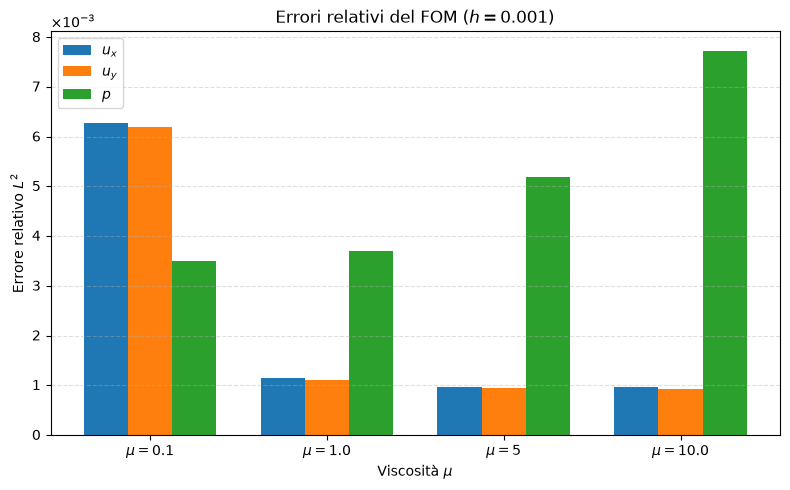

In [7]:
# GRAFICO 0: errori relativi rispetto a soluzione esatta per ogni componente della soluzione
from matplotlib.ticker import ScalarFormatter

h_fixed = 0.001
mu_values = nu_values
err_ux = [results[mu][h_fixed]["err_ux_rel"] for mu in mu_values]
err_uy = [results[mu][h_fixed]["err_uy_rel"] for mu in mu_values]
err_p  = [results[mu][h_fixed]["err_p_rel"]  for mu in mu_values]
x = np.arange(len(mu_values))
width = 0.25
plt.figure(figsize=(8,5))
plt.bar(x - width, err_ux, width, label=r"$u_x$")
plt.bar(x,         err_uy, width, label=r"$u_y$")
plt.bar(x + width, err_p,  width, label=r"$p$")
plt.xticks(x, [rf"$\mu={mu}$" for mu in mu_values])
plt.xlabel(r"Viscosità $\mu$")
plt.ylabel(r"Errore relativo $L^2$")
plt.title(r"Errori relativi del FOM ($h=0.001$)")
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0,0))
ax = plt.gca()
ax.yaxis.set_major_formatter(formatter)
plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
# GRAFICO 1: distanza relativa tra soluzione newton e soluzione esatta
def plot_errori_newton(nu, h):
    errori_assoluti = results[nu][h]["errori_newton"]
    norma_alpha     = results[nu][h]["norma_alpha"]

    errori_relativi = [e / norma_alpha for e in errori_assoluti]
    iterazioni      = list(range(1, len(errori_relativi) + 1))

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.semilogy(iterazioni, errori_relativi, 'o-', color='steelblue', linewidth=2, markersize=8)
    ax.set_title(f'Errore relativo vs soluzione esatta  (ν = {nu}, h = {h})', fontsize=13)
    ax.set_xlabel('Iterazione k', fontsize=12)
    ax.set_ylabel(r'$\|u_k - u_{exact}\|_2 \; / \; \|u_{exact}\|_2$', fontsize=12)
    ax.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


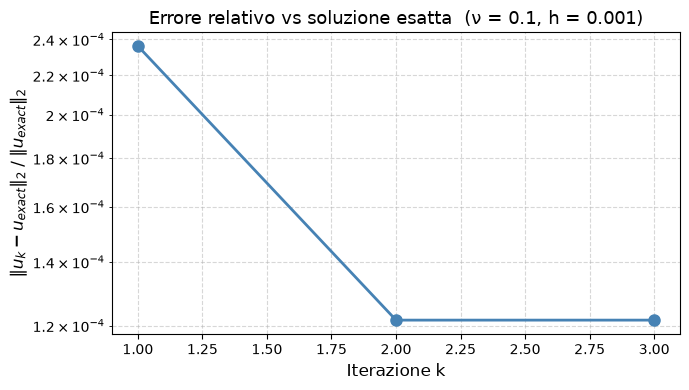

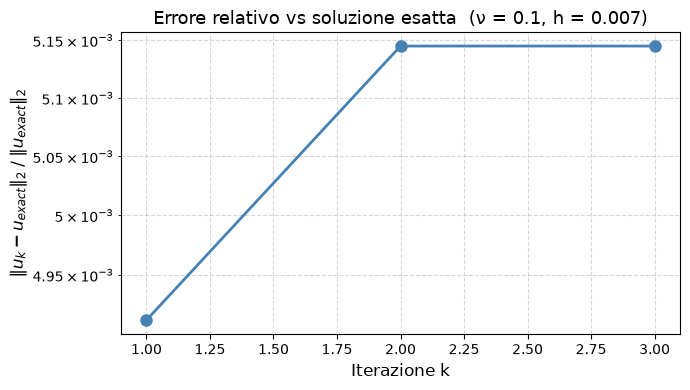

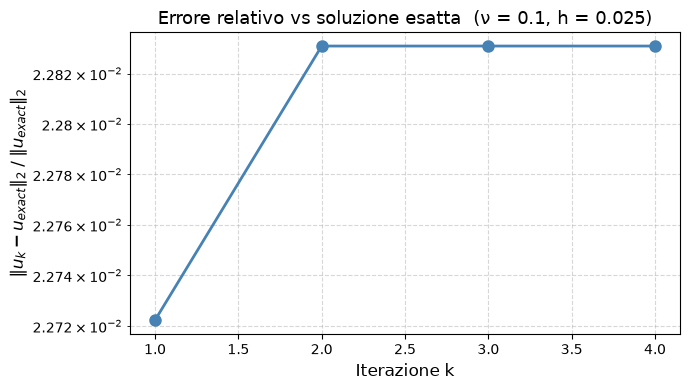

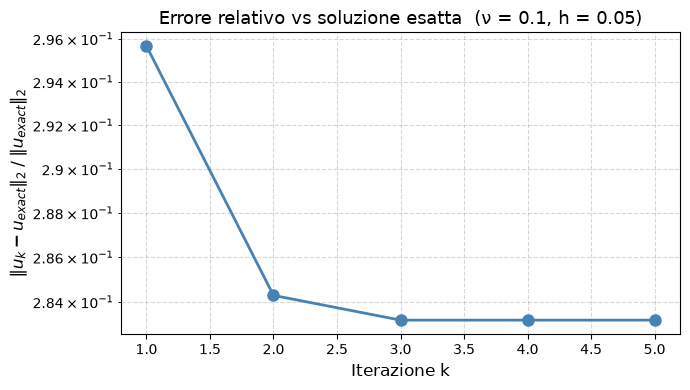

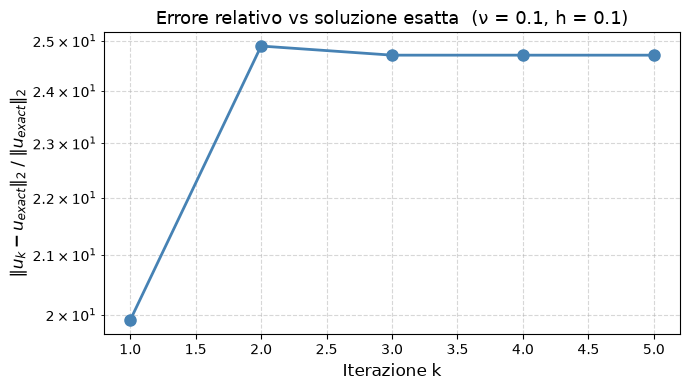

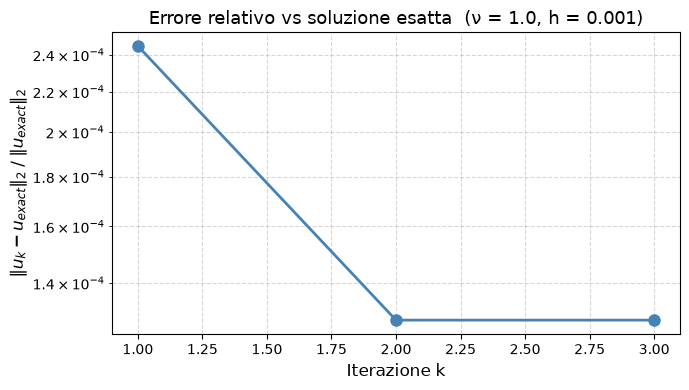

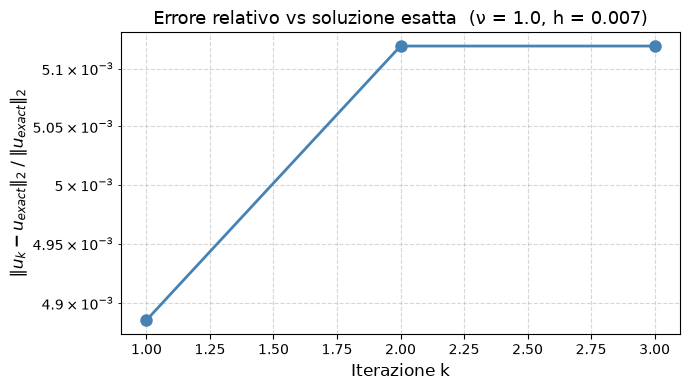

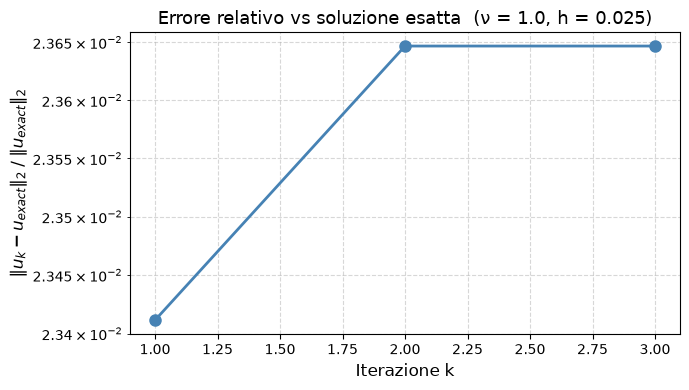

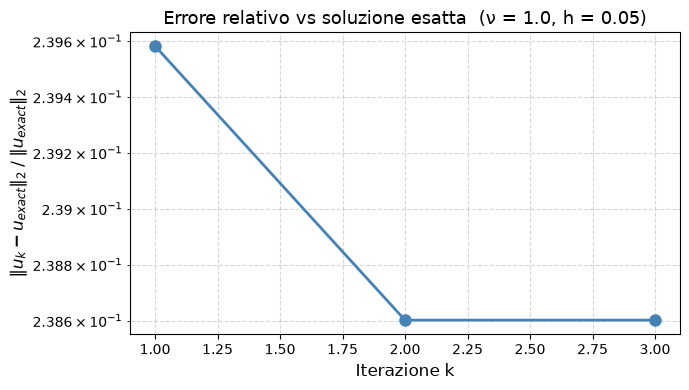

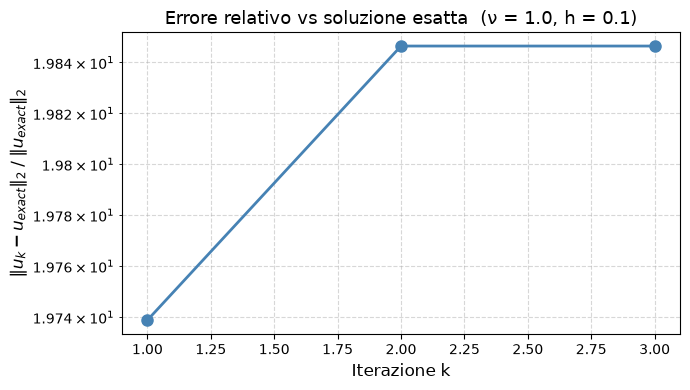

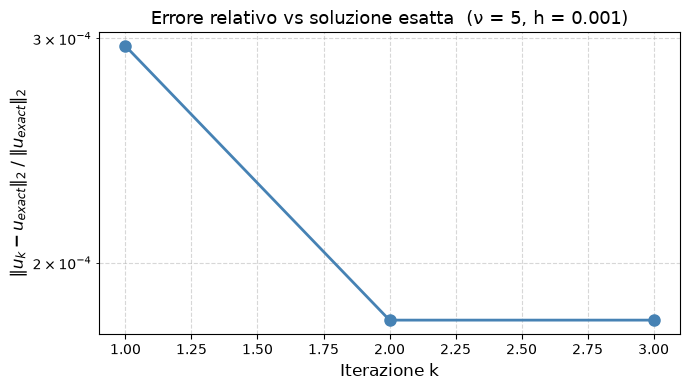

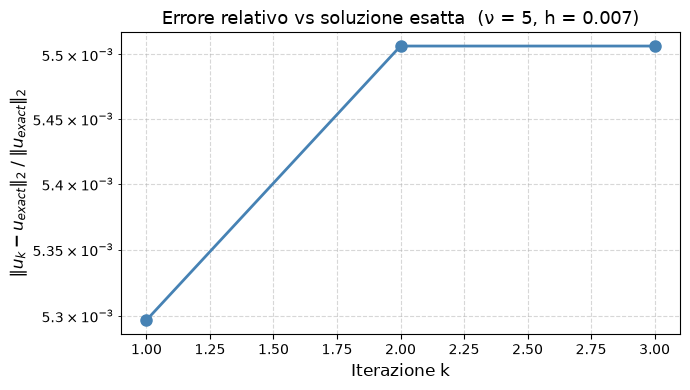

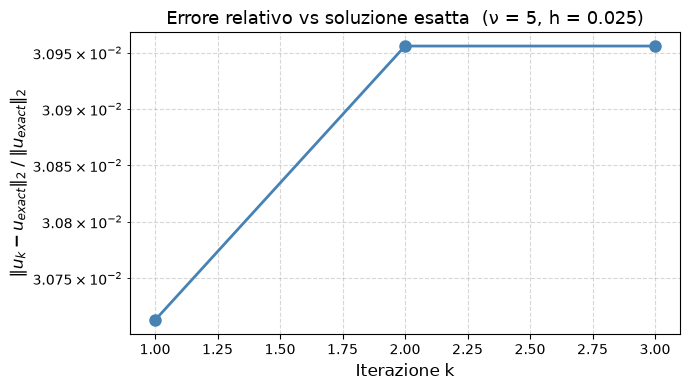

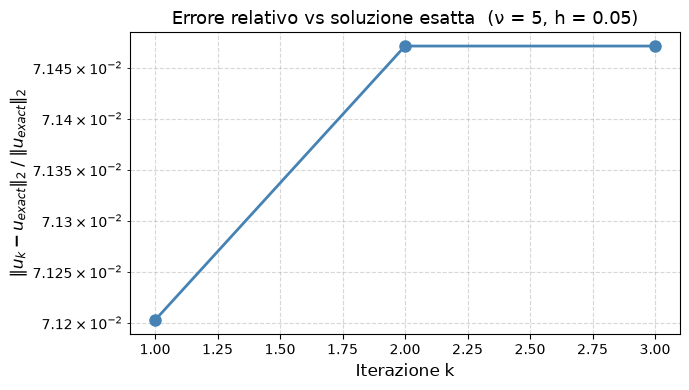

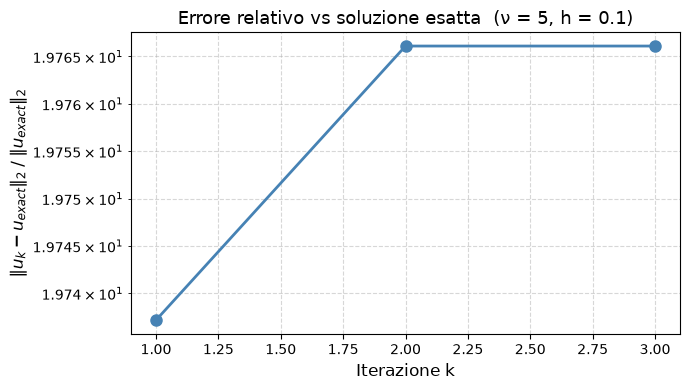

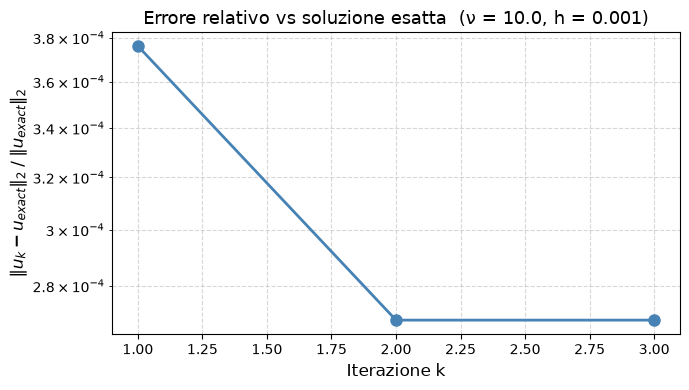

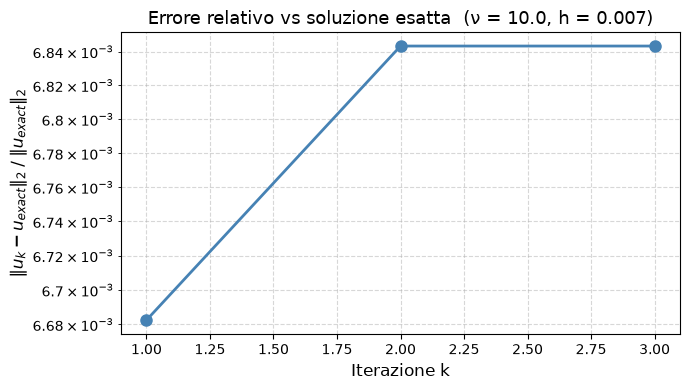

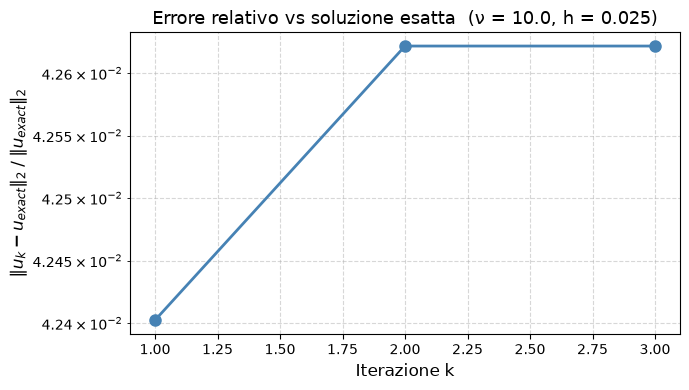

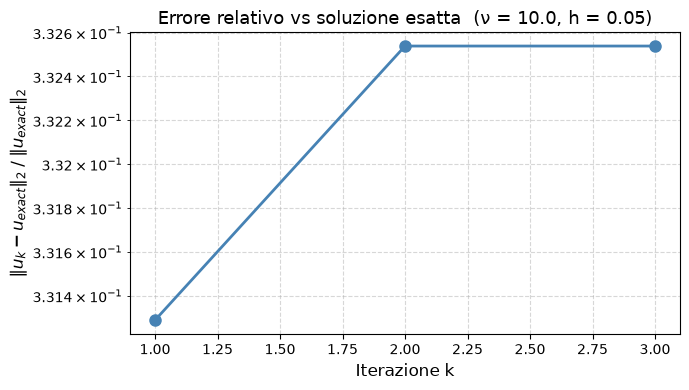

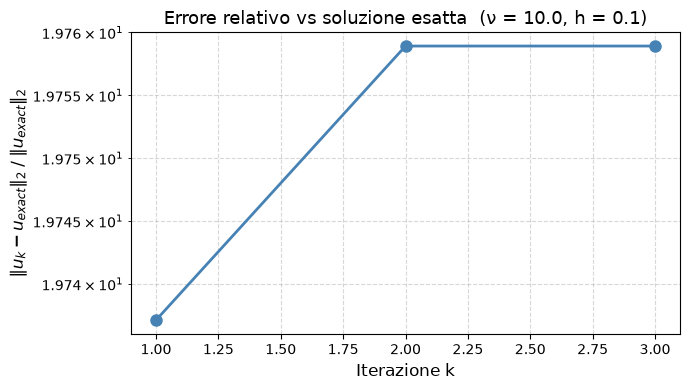

'nu_values   = [0.1, 1.0 10.0]          # μ₀ ∈ [0.1, 10] come da testo\nmesh_sizes  = [0.001,   0.025,   0.05,   0.1,  0.2 ]   # h decrescente per test di convergenza'

In [9]:
# Tutte le combinazioni parametro - mesh size:
for nu in nu_values:
    for h in mesh_sizes:
        plot_errori_newton(nu, h)
'''nu_values   = [0.1, 1.0 10.0]          # μ₀ ∈ [0.1, 10] come da testo
mesh_sizes  = [0.001,   0.025,   0.05,   0.1,  0.2 ]   # h decrescente per test di convergenza'''

In [10]:
# GRAFICO 2: norma della differenza tra iterazione corrente e precedente, divisa per norma corrente
# ovvero grafico residuo relativo

def plot_residui_newton(nu, h):
    residui    = results[nu][h]["residui_relativi"]
    iterazioni = list(range(1, len(residui) + 1))

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.semilogy(iterazioni, residui, 'o-', color='darkorange', linewidth=2, markersize=8)
    ax.set_title(f'Residuo relativo Newton  (ν = {nu}, h = {h})', fontsize=13)
    ax.set_xlabel('Iterazione k', fontsize=12)
    ax.set_ylabel(r'$\|u_k - u_{k-1}\|_2 \; / \; \|u_k\|_2$', fontsize=12)
    ax.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


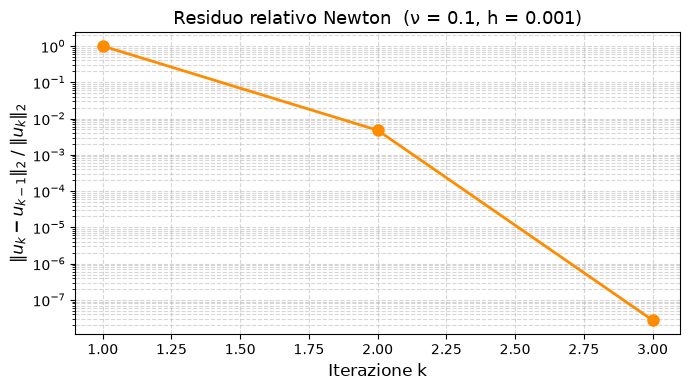

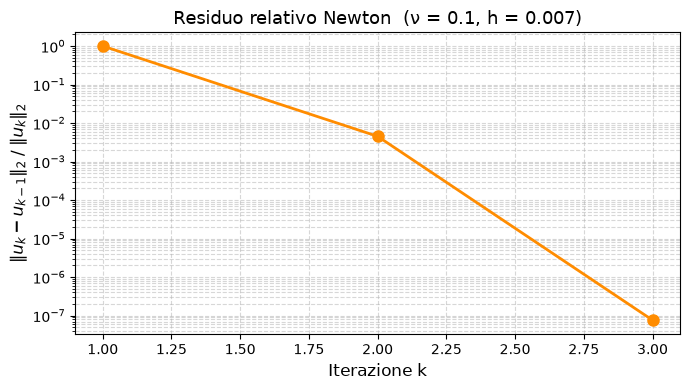

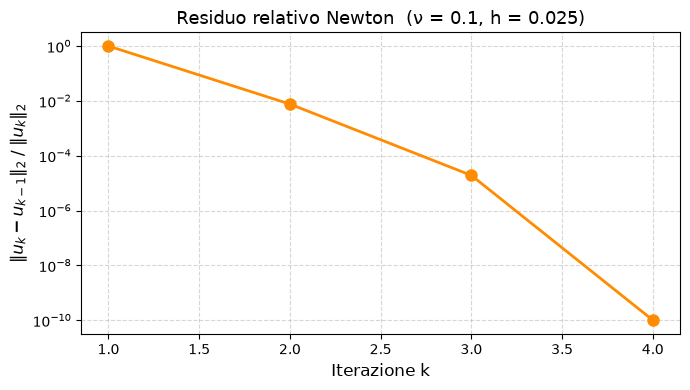

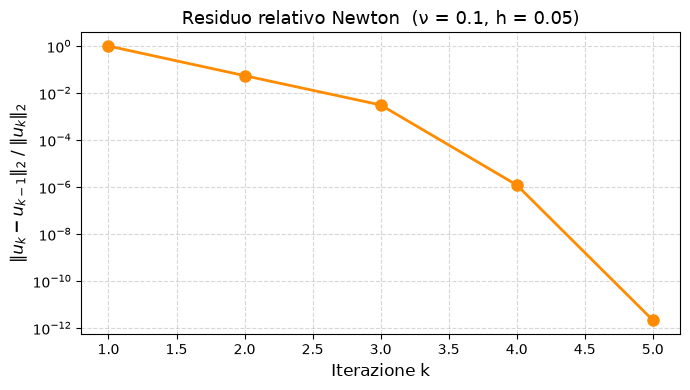

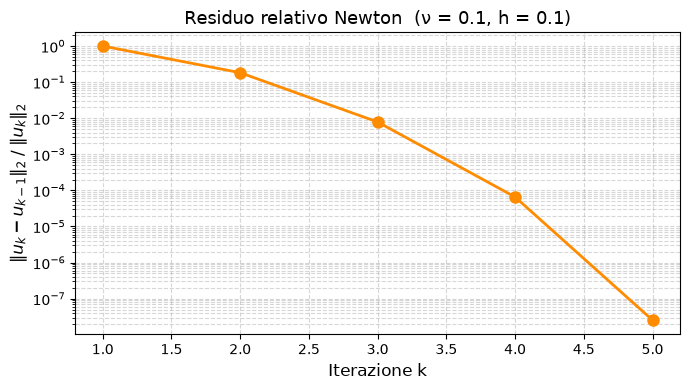

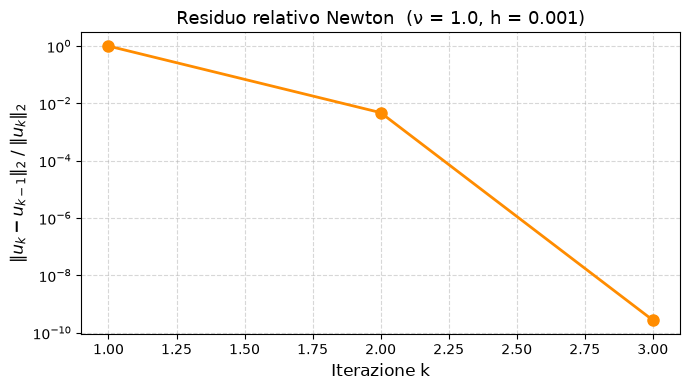

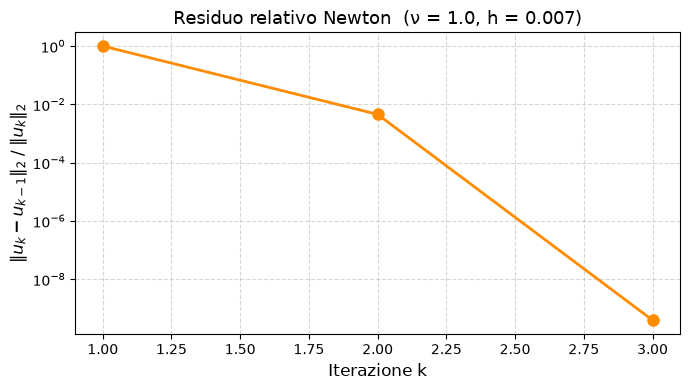

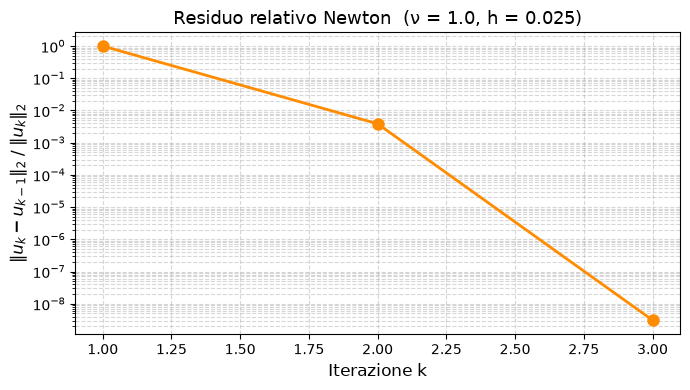

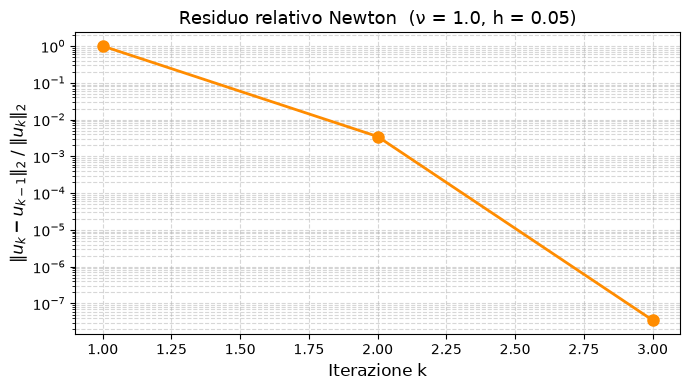

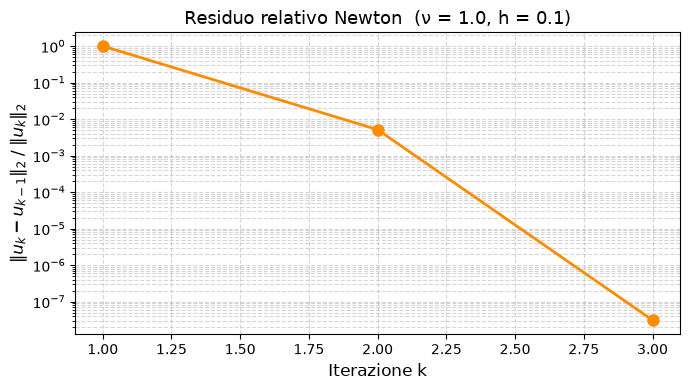

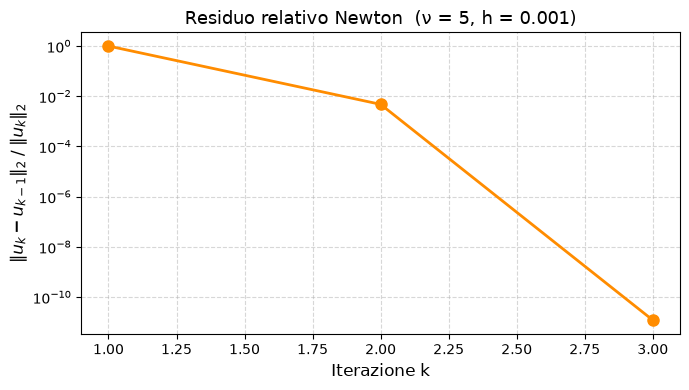

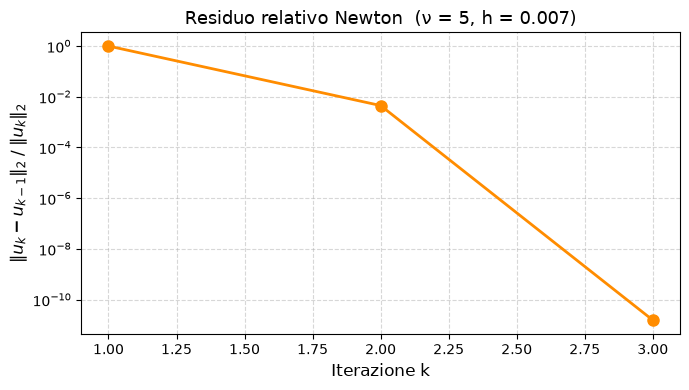

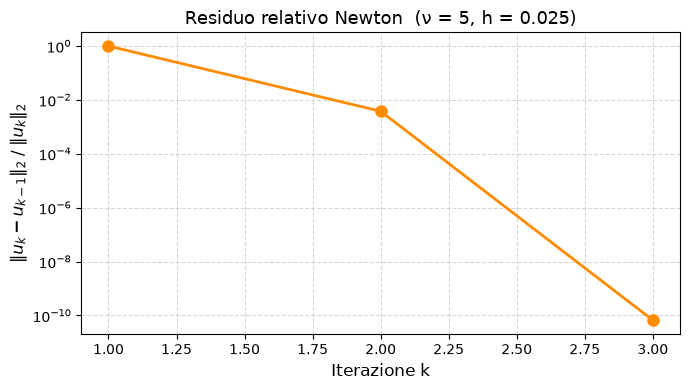

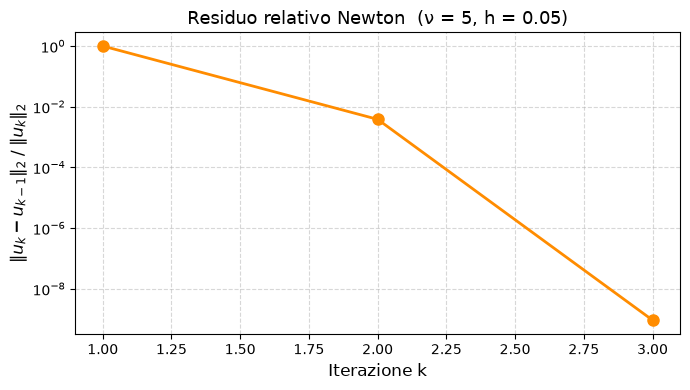

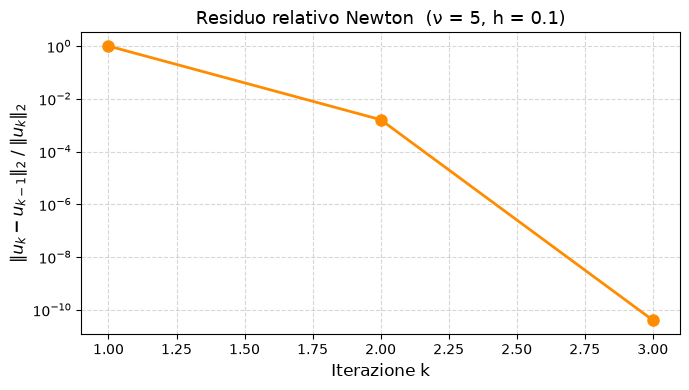

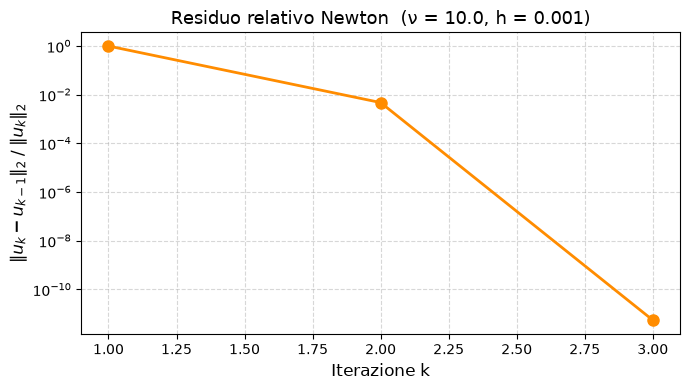

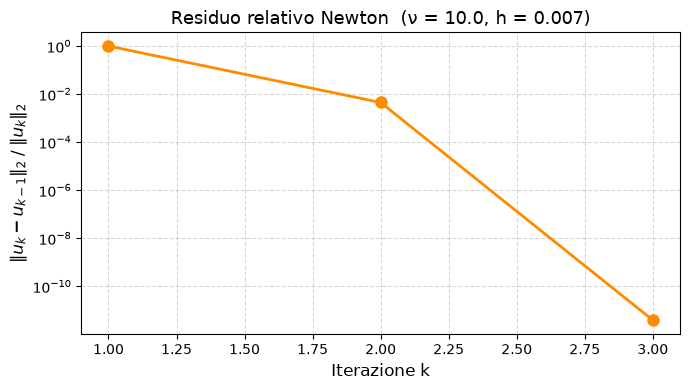

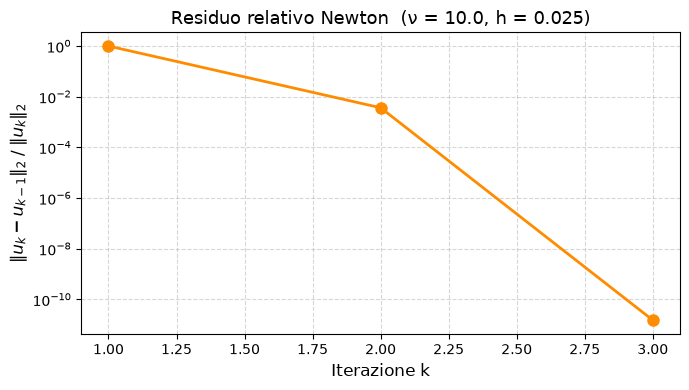

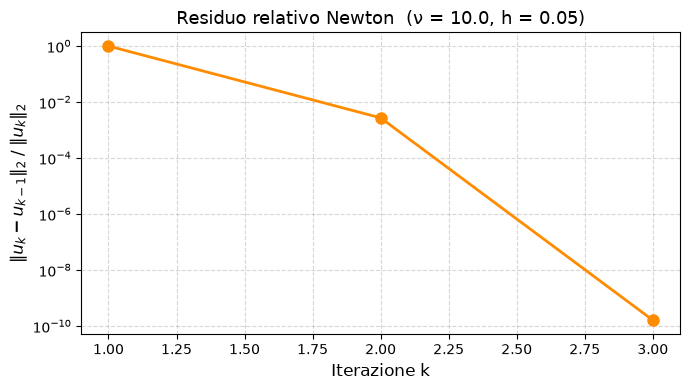

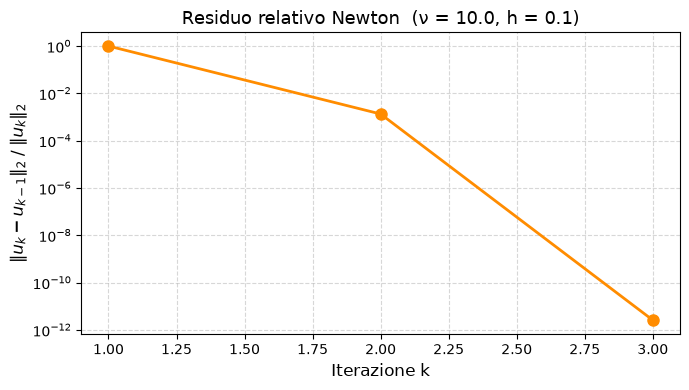

In [11]:
# Tutte le combinazioni parametro - mesh size:
for nu in nu_values:
    for h in mesh_sizes:
        plot_residui_newton(nu, h)

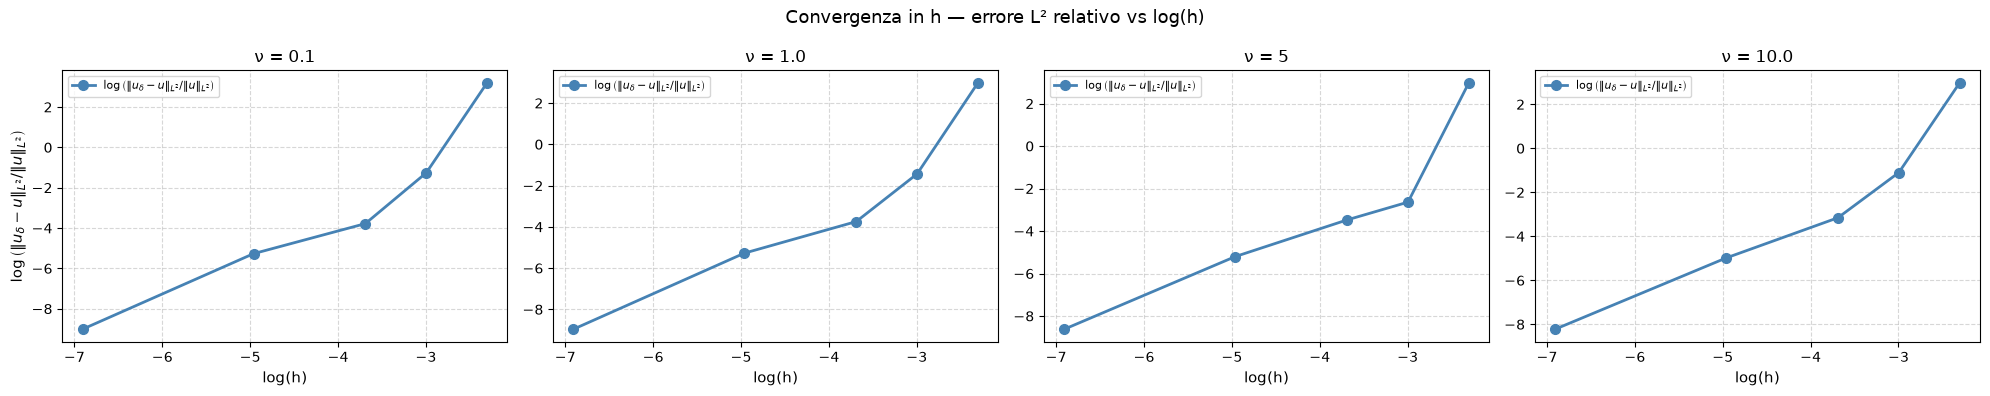

In [12]:
# GRAFICO 3: andamento errore (distanza soluzione FOM a soluzione esatta al crescere della dimensione della mesh (mesh meno fine))
# ci dovremmo aspettare un andamento tc log(err) e log(h) è una retta con coefficiente angolare positivo
fig, axes = plt.subplots(1, len(nu_values), figsize=(5*len(nu_values), 4), sharey=False)

for ax, nu in zip(axes, nu_values):
    hs      = mesh_sizes
    log_h   = [np.log(h) for h in hs]

    # errore relativo: ||u_delta - u|| / ||u_exact||
    log_err = [np.log(results[nu][h]["err_totale"] / results[nu][h]["norma_alpha"]) for h in hs]

    ax.plot(log_h, log_err, 'o-', color='steelblue', linewidth=2, markersize=7,
            label=r'$\log\left(\|u_\delta - u\|_{L^2} / \|u\|_{L^2}\right)$')

    ax.set_title(f'ν = {nu}', fontsize=12)
    ax.set_xlabel('log(h)', fontsize=11)
    if ax == axes[0]:
        ax.set_ylabel(r'$\log\left(\|u_\delta - u\|_{L^2} / \|u\|_{L^2}\right)$', fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Convergenza in h — errore L² relativo vs log(h)', fontsize=13)
plt.tight_layout()
plt.savefig('convergenza_h_log.png', dpi=150)
plt.show()

# DA QUI CODICE UGUALE A QUELLO DELL'ESERCITAZIONE (usato per parte sopra)

In [13]:
geometry_utilities_config = gedim.GeometryUtilitiesConfig()
geometry_utilities_config.tolerance1_d = 1.0e-6
geometry_utilities_config.tolerance2_d = 1.0e-12
geometry_utilities = gedim.GeometryUtilities(geometry_utilities_config)
mesh_utilities = gedim.MeshUtilities()
vtk_utilities = ExportVTKUtilities()

In [14]:
# Export folder
export_file_path = "./Export/Test_1"
if not os.path.exists(export_file_path):
    os.makedirs(export_file_path)

# Mesh file path
export_mesh_path = export_file_path + "/Mesh"
if not os.path.exists(export_mesh_path):
    os.makedirs(export_mesh_path)

# Solution file path
export_solution_path = export_file_path + "/Solution"
if not os.path.exists(export_solution_path):
    os.makedirs(export_solution_path)

### Discretization

In [15]:
pde_domain = polydim.pde_tools.mesh.pde_mesh_utilities.PDE_Domain_2D()
pde_domain.vertices = np.array([[0.0, 1.0, 1.0, 0.0],
                                [0.0, 0.0, 1.0, 1.0],
                                [0.0, 0.0, 0.0, 0.0]])
pde_domain.shape_type = polydim.pde_tools.mesh.pde_mesh_utilities.PDE_Domain_2D.Domain_Shape_Types.parallelogram
pde_domain.area = 1.0

In [16]:
mesh_type = polydim.pde_tools.mesh.pde_mesh_utilities.MeshGenerator_Types_2D.triangular
method_type = polydim.pde_tools.local_space_pcc_2_d.MethodTypes.fem_pcc
mesh_size = 0.001   # mesh_size è il parametro h — cioè la dimensione caratteristica degli elementi della mesh. 
# Indica la lunghezza massima (o tipica) dello spigolo di un triangolo. Errore scala con tale taglia: ‖u − u_h‖ ≤ C · h^k

In [17]:
mesh_data = gedim.MeshMatrices()
mesh = gedim.MeshMatricesDAO(mesh_data)

polydim.pde_tools.mesh.pde_mesh_utilities.create_mesh_2_d(geometry_utilities,
                                                          mesh_utilities,
                                                          mesh_type,
                                                          pde_domain,
                                                          mesh_size,
                                                          mesh)
mesh_geometric_data = polydim.pde_tools.mesh.pde_mesh_utilities.compute_mesh_2_d_geometry_data(geometry_utilities, mesh_utilities, mesh)

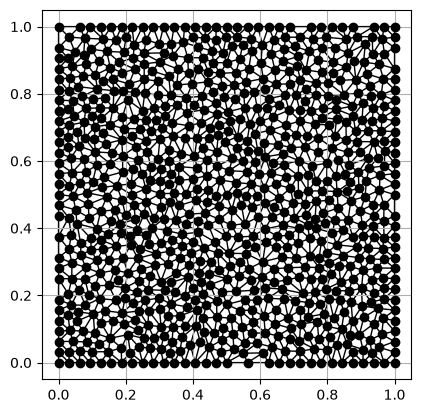

In [18]:
vtk_utilities.export_mesh(export_mesh_path, mesh)
other_ut.plot_mesh(mesh)

In [19]:
info_internal = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.none)
info_internal.marker = 0

info_dirichlet = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.strong)
info_dirichlet.marker = 1

info_neumann_none = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.none)
info_neumann_none.marker = 0

pressure_boundary_info = {
    0: info_internal,
    1: info_dirichlet,
    2: info_neumann_none,
    3: info_neumann_none,
    4: info_neumann_none,
    5: info_neumann_none,
    6: info_neumann_none,
    7: info_neumann_none,
    8: info_neumann_none
}

speed_boundary_info = {
    0: info_internal,
    1: info_dirichlet,
    2: info_dirichlet,
    3: info_dirichlet,
    4: info_dirichlet,
    5: info_dirichlet,
    6: info_dirichlet,
    7: info_dirichlet,
    8: info_dirichlet
}

In [20]:
mesh_connectivity_data = polydim.pde_tools.mesh.MeshMatricesDAO_mesh_connectivity_data(mesh)

pressure_reference_element_data = polydim.pde_tools.local_space_pcc_2_d.create_reference_element(method_type, 
                                                                                              1)
speed_reference_element_data = polydim.pde_tools.local_space_pcc_2_d.create_reference_element(method_type, 
                                                                                             2)

dof_manager = polydim.pde_tools.do_fs.DOFsManager()

pressure_mesh_dofs_info = polydim.pde_tools.local_space_pcc_2_d.set_mesh_do_fs_info(pressure_reference_element_data, 
                                                                                    mesh, 
                                                                                    pressure_boundary_info)
pressure_dofs_data = dof_manager.create_do_fs_2_d(pressure_mesh_dofs_info, 
                                                  mesh_connectivity_data)

speed_mesh_dofs_info = polydim.pde_tools.local_space_pcc_2_d.set_mesh_do_fs_info(speed_reference_element_data, 
                                                                                 mesh, 
                                                                                 speed_boundary_info)
speed_dofs_data = dof_manager.create_do_fs_2_d(speed_mesh_dofs_info, 
                                               mesh_connectivity_data)

In [21]:
pressure_n_dofs = pressure_dofs_data.number_do_fs
pressure_n_strongs = pressure_dofs_data.number_strongs
speed_n_dofs = speed_dofs_data.number_do_fs
speed_n_strongs = speed_dofs_data.number_strongs
tot_dofs = 2 * speed_n_dofs + pressure_n_dofs
tot_strongs = 2 * speed_n_strongs + pressure_n_strongs
# I DOFs (Degrees of Freedom) sono i valori incogniti che il metodo FEM deve calcolare — cioè i valori della soluzione nei punti "liberi" della mesh.
# In FEM non cerchi la funzione continua u(x) direttamente — la approssimi come combinazione lineare di funzioni base. I DOFs sono i coefficienti uᵢ u_h(x) = Σᵢ uᵢ · φᵢ(x)

In [22]:
print("P dofs\t", "P stgs\t", "U dofs\t", "U stgs\t", "T dofs\t", "T stgs")
print(pressure_n_dofs,"\t", pressure_n_strongs,"\t", speed_n_dofs,"\t", speed_n_strongs,"\t", tot_dofs,"\t", tot_strongs)

P dofs	 P stgs	 U dofs	 U stgs	 T dofs	 T stgs
829 	 1 	 2966 	 234 	 6761 	 469


### Validazione codice: definizione soluzione nota
La soluzione non è nota a priori quindi per verificare il codice (andare a confrontare soluzione ottenuta con soluzione esatta tramite compute errors) andiamo a definire una soluzione e a calcolarci i forcing term di tale soluzione
La soluzione scelta è quella nel laboratorio ROMStoke 

In [23]:
nu = 0.1

def pressure_exact(x, y, z):
    return np.pi * np.pi * np.sin(2.0 * np.pi * x) * np.cos(2.0 * np.pi * y)

def pressure_exact_gradient(x, y, z):
    return np.array([\
        +2.0 * np.pi * np.pi * np.pi * np.cos(2.0 * np.pi * x) * np.cos(2.0 * np.pi * y),\
        -2.0 * np.pi * np.pi * np.pi * np.sin(2.0 * np.pi * x) * np.sin(2.0 * np.pi * y),\
        0.0])

def speed_x_exact(x, y, z):
    return +0.5 * np.sin(2.0 * np.pi * x) * np.sin(2.0 * np.pi * x) * np.sin(2.0 * np.pi * y) * np.cos(2.0 * np.pi * y)
def speed_y_exact(x, y, z):
    return -0.5 * np.sin(2.0 * np.pi * y) * np.sin(2.0 * np.pi * y) * np.sin(2.0 * np.pi * x) * np.cos(2.0 * np.pi * x)

def speed_x_exact_laplacian(x, y, z):
    return +2.0 * np.pi * np.pi * np.sin(4.0 * np.pi * y) * (2.0 * np.cos(4.0 * np.pi * x) - 1.0)
def speed_y_exact_laplacian(x, y, z):
    return -2.0 * np.pi * np.pi * np.sin(4.0 * np.pi * x) * (2.0 * np.cos(4.0 * np.pi * y) - 1.0)

In [24]:
def pressure_strong_function(marker, x, y, z):  
    return pressure_exact(x, y, z)

p_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       pressure_mesh_dofs_info,
                                                                       pressure_dofs_data,
                                                                       pressure_reference_element_data,
                                                                       pressure_strong_function)
def speed_x_strong_function(marker, x, y, z):  
    return speed_x_exact(x, y, z)
def speed_y_strong_function(marker, x, y, z):  
    return speed_y_exact(x, y, z)

# soluzioni esatte

u_x_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_mesh_dofs_info,
                                                                       speed_dofs_data,
                                                                       speed_reference_element_data,
                                                                       speed_x_strong_function)
u_y_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_mesh_dofs_info,
                                                                       speed_dofs_data,
                                                                       speed_reference_element_data,
                                                                       speed_y_strong_function)

#### definiamo la forzante (termine a destra)
La forzante è quella nel laib ROMstokes:

In [25]:
nu = 0.1  # ← deve coincidere con nu_term sotto

def f_x_function(x, y, z):
    # Termine diffusivo: -nu * Δu_x
    diff = -nu * speed_x_exact_laplacian(x, y, z)

    # Termine convettivo: u_x * ∂u_x/∂x + u_y * ∂u_x/∂y
    ux = speed_x_exact(x, y, z)
    uy = speed_y_exact(x, y, z)
    dux_dx = 0.5 * np.pi * np.sin(4*np.pi*x) * np.sin(4*np.pi*y)
    dux_dy = np.pi * np.sin(2*np.pi*x)**2 * np.cos(4*np.pi*y)
    conv = ux * dux_dx + uy * dux_dy

    # Gradiente di pressione: ∂p/∂x
    dp_dx = pressure_exact_gradient(x, y, z)[0]

    return diff + conv + dp_dx

def f_y_function(x, y, z):
    # Termine diffusivo: -nu * Δu_y
    diff = -nu * speed_y_exact_laplacian(x, y, z)

    # Termine convettivo: u_x * ∂u_y/∂x + u_y * ∂u_y/∂y
    ux = speed_x_exact(x, y, z)
    uy = speed_y_exact(x, y, z)
    duy_dx = -np.pi * np.sin(2*np.pi*y)**2 * np.cos(4*np.pi*x)
    duy_dy = -0.5 * np.pi * np.sin(4*np.pi*x) * np.sin(4*np.pi*y)
    conv = ux * duy_dx + uy * duy_dy

    # Gradiente di pressione: ∂p/∂y
    dp_dy = pressure_exact_gradient(x, y, z)[1]

    return diff + conv + dp_dy

f_x = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       speed_reference_element_data,
                                                                       speed_reference_element_data,
                                                                       f_x_function)
f_y = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       speed_reference_element_data,
                                                                       speed_reference_element_data,
                                                                       f_y_function)

f_S = np.concatenate([f_x, f_y, np.zeros(pressure_n_dofs)])

### High Fidelity approximation

## High fidelity
Gestiamo i termini lineari: termine diffusive e advection (entrambi lineari), il termine non lineare c verrà gestito direttamente in newton

In [26]:
def nu_term(x, y, z):
    return nu  
def b_x_term(x, y, z):  
    return np.array([\
        1.0,\
        0.0,\
        0.0])
def b_y_term(x, y, z):  
    return np.array([\
        0.0,\
        1.0,\
        0.0])

# vedi appunti
A_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_diffusion_operator(geometry_utilities,
                                                                                       mesh,
                                                                                       mesh_geometric_data,
                                                                                       speed_dofs_data,
                                                                                       speed_dofs_data,
                                                                                       speed_reference_element_data,
                                                                                       speed_reference_element_data,
                                                                                       nu_term)



# Crea una matrice sparsa di dimensione tot_dofs × tot_dofs e inserisce A con offset [0, 0], cioè nel blocco in alto a sinistra
J_A_x = other_ut.make_np_sparse(A_operator.operator_dofs, [tot_dofs, tot_dofs], [0, 0])
J_A_y = other_ut.make_np_sparse(A_operator.operator_dofs, [tot_dofs, tot_dofs], [speed_n_dofs, speed_n_dofs])


B_x_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_advection_operator(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       pressure_dofs_data,
                                                                       speed_reference_element_data,
                                                                       pressure_reference_element_data,
                                                                       b_x_term)
B_y_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_advection_operator(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       pressure_dofs_data,
                                                                       speed_reference_element_data,
                                                                       pressure_reference_element_data,
                                                                       b_y_term)

J_B_x = other_ut.make_np_sparse(B_x_operator.operator_dofs, [tot_dofs, tot_dofs], [2 * speed_n_dofs, 0])
J_B_y = other_ut.make_np_sparse(B_y_operator.operator_dofs, [tot_dofs, tot_dofs], [2 * speed_n_dofs, speed_n_dofs])
J_BT_x = other_ut.make_np_sparse(B_x_operator.operator_dofs, [tot_dofs, tot_dofs], [2 * speed_n_dofs, 0], True)
J_BT_y = other_ut.make_np_sparse(B_y_operator.operator_dofs, [tot_dofs, tot_dofs], [2 * speed_n_dofs, speed_n_dofs], True)


J_S = J_A_x + J_A_y - J_B_x - J_B_y - J_BT_x - J_BT_y

La forzante f_s era già stata definita prima

## Newton

#### Inizializzazione Newton

In [27]:
# Newton parte dalla soluzione nulla
def speed_x_initial_condition(x, y, z):  
    return 0.0
def speed_y_initial_condition(x, y, z):  
    return 0.0
def pressure_initial_condition(x, y, z):  
    return 0.0


# Sono le proiezioni questa funzione nello spazio FEM delle soluzioni iniziali (che sono nulle)
u_x_numeric = polydim.pde_tools.assembler_utilities.pcc_2_d.evaluate_function_on_dofs(geometry_utilities,
                                                                                mesh,
                                                                                mesh_geometric_data,
                                                                                speed_dofs_data,
                                                                                speed_reference_element_data,
                                                                                speed_x_initial_condition).function_dofs
u_y_numeric = polydim.pde_tools.assembler_utilities.pcc_2_d.evaluate_function_on_dofs(geometry_utilities,
                                                                                mesh,
                                                                                mesh_geometric_data,
                                                                                speed_dofs_data,
                                                                                speed_reference_element_data,
                                                                                speed_y_initial_condition).function_dofs
p_numeric = polydim.pde_tools.assembler_utilities.pcc_2_d.evaluate_function_on_dofs(geometry_utilities,
                                                                                mesh,
                                                                                mesh_geometric_data,
                                                                                pressure_dofs_data,
                                                                                pressure_reference_element_data,
                                                                                pressure_initial_condition).function_dofs

u_k = np.concatenate([u_x_numeric, u_y_numeric, p_numeric])

# delta (la correzione usata in Newton)
du_x_strong = np.zeros(speed_n_strongs)
du_y_strong = np.zeros(speed_n_strongs)
dp_strong = np.zeros(pressure_n_strongs)
residual_norm = 1.0
solution_norm = 1.0

# criterio di arresto
newton_tol = 1.0e-6
max_iterations = 10
num_iteration = 1

#### iterazioni Newton

In [28]:
while num_iteration < max_iterations and residual_norm > newton_tol * solution_norm: 
    c_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_ns_operators(geometry_utilities,
                                                                                     mesh,
                                                                                     mesh_geometric_data,
                                                                                     speed_dofs_data,
                                                                                     speed_reference_element_data,
                                                                                     u_x_numeric,
                                                                                     u_y_numeric,
                                                                                     u_x_strong,
                                                                                     u_y_strong)
    
    J_C = other_ut.make_np_sparse(c_operator.convective_operator.operator_dofs, [tot_dofs, tot_dofs], [0, 0])
    f_C = np.concatenate([c_operator.convective_rhs, np.zeros(pressure_n_dofs)])

    J_f = f_S - f_C - J_S @ u_k
    du = scipy.sparse.linalg.spsolve(J_S + J_C, J_f)  # J_S + J_C è lo jacobiano totale ma solo in questo caso che la forzante è supposta costante perchè 
      # ho fissato una soluzione e ho trovato il valore della forzante rispettivo, in generale altrimenti dovrò considerarlo diverso da 0
    
    u_k = u_k + du

    du_x = du[0:speed_n_dofs]
    du_y = du[speed_n_dofs:2 * speed_n_dofs]
    dp = du[2 * speed_n_dofs:]

    u_x_numeric = u_k[0:speed_n_dofs]
    u_y_numeric = u_k[speed_n_dofs:2 * speed_n_dofs]
    p_numeric = u_k[2 * speed_n_dofs:]
    
    du_x_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                 mesh,
                                                                                 mesh_geometric_data,
                                                                                 speed_dofs_data,
                                                                                 speed_reference_element_data,
                                                                                 du_x,
                                                                                 du_x_strong)
    du_y_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                 mesh,
                                                                                 mesh_geometric_data,
                                                                                 speed_dofs_data,
                                                                                 speed_reference_element_data,
                                                                                 du_y,
                                                                                 du_y_strong)
    dp_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                 mesh,
                                                                                 mesh_geometric_data,
                                                                                 pressure_dofs_data,
                                                                                 pressure_reference_element_data,
                                                                                 dp,
                                                                                 dp_strong)
    u_x_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                mesh,
                                                                                mesh_geometric_data,
                                                                                speed_dofs_data,
                                                                                speed_reference_element_data,
                                                                                u_x_numeric,
                                                                                u_x_strong,
                                                                                speed_x_exact)
    u_y_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                mesh,
                                                                                mesh_geometric_data,
                                                                                speed_dofs_data,
                                                                                speed_reference_element_data,
                                                                                u_y_numeric,
                                                                                u_y_strong,
                                                                                speed_y_exact)
    p_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                mesh,
                                                                                mesh_geometric_data,
                                                                                pressure_dofs_data,
                                                                                pressure_reference_element_data,
                                                                                p_numeric,
                                                                                p_strong,
                                                                                pressure_exact)
       
    solution_norm = np.sqrt(u_x_error_L2.numeric_norm_l2 * u_x_error_L2.numeric_norm_l2 + 
                           u_y_error_L2.numeric_norm_l2 * u_y_error_L2.numeric_norm_l2 +
                           p_error_L2.numeric_norm_l2 * p_error_L2.numeric_norm_l2);
    residual_norm = np.sqrt(du_x_error_L2.numeric_norm_l2 * du_x_error_L2.numeric_norm_l2 + 
                           du_y_error_L2.numeric_norm_l2 * du_y_error_L2.numeric_norm_l2 +
                           dp_error_L2.numeric_norm_l2 * dp_error_L2.numeric_norm_l2);

    print("dofs", "u_x_errorL2", "u_y_errorL2", "p_errorL2", "residual", "iteration", "max_iteration")
    print(tot_dofs, '{:.2e}'.format(u_x_error_L2.error_l2 / u_x_error_L2.numeric_norm_l2), '{:.2e}'.format(u_y_error_L2.error_l2 / u_y_error_L2.numeric_norm_l2), '{:.2e}'.format(p_error_L2.error_l2 / p_error_L2.numeric_norm_l2), '{:.16e}'.format(residual_norm / solution_norm), '{:d}'.format(num_iteration), '{:d}'.format(max_iterations))
    
    num_iteration = num_iteration + 1

dofs u_x_errorL2 u_y_errorL2 p_errorL2 residual iteration max_iteration
6761 6.66e-03 6.60e-03 6.80e-03 1.0000000000000000e+00 1 10
dofs u_x_errorL2 u_y_errorL2 p_errorL2 residual iteration max_iteration
6761 6.28e-03 6.19e-03 3.50e-03 4.8626723057946433e-03 2 10
dofs u_x_errorL2 u_y_errorL2 p_errorL2 residual iteration max_iteration
6761 6.28e-03 6.19e-03 3.50e-03 2.7568110407931833e-08 3 10


In [29]:
u_x_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                mesh,
                                                                                mesh_geometric_data,
                                                                                speed_dofs_data,
                                                                                speed_reference_element_data,
                                                                                u_x_numeric,
                                                                                u_x_strong,
                                                                                speed_x_exact)
print("dofs", "errorL2")
print(speed_dofs_data.number_do_fs, '{:.2e}'.format(u_x_error_L2.error_l2 / u_x_error_L2.numeric_norm_l2))

dofs errorL2
2966 6.28e-03


In [30]:
u_y_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                mesh,
                                                                                mesh_geometric_data,
                                                                                speed_dofs_data,
                                                                                speed_reference_element_data,
                                                                                u_y_numeric,
                                                                                u_y_strong,
                                                                                speed_y_exact)
print("dofs", "errorL2")
print(speed_dofs_data.number_do_fs, '{:.2e}'.format(u_y_error_L2.error_l2 / u_y_error_L2.numeric_norm_l2))

dofs errorL2
2966 6.19e-03


In [31]:
p_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                mesh,
                                                                                mesh_geometric_data,
                                                                                pressure_dofs_data,
                                                                                pressure_reference_element_data,
                                                                                p_numeric,
                                                                                p_strong,
                                                                                pressure_exact)
print("dofs", "errorL2")
print(pressure_dofs_data.number_do_fs, '{:.2e}'.format(p_error_L2.error_l2 / p_error_L2.numeric_norm_l2))

dofs errorL2
829 3.50e-03


In [32]:
u_x_on_cell0Ds = polydim.pde_tools.assembler_utilities.pcc_2_d.extract_solution_on_cell0_ds(mesh,
                                                                       speed_dofs_data,
                                                                                         u_x_numeric,
                                                                                         u_x_strong,
                                                                       speed_x_exact)
u_y_on_cell0Ds = polydim.pde_tools.assembler_utilities.pcc_2_d.extract_solution_on_cell0_ds(mesh,
                                                                       speed_dofs_data,
                                                                                         u_y_numeric,
                                                                                         u_y_strong,
                                                                       speed_y_exact)
p_on_cell0Ds = polydim.pde_tools.assembler_utilities.pcc_2_d.extract_solution_on_cell0_ds(mesh,
                                                                       pressure_dofs_data,
                                                                                         p_numeric,
                                                                                         p_strong,
                                                                       pressure_exact)

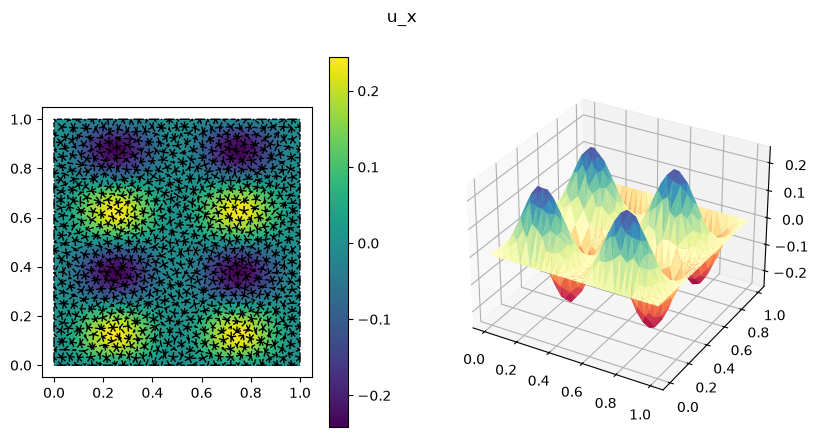

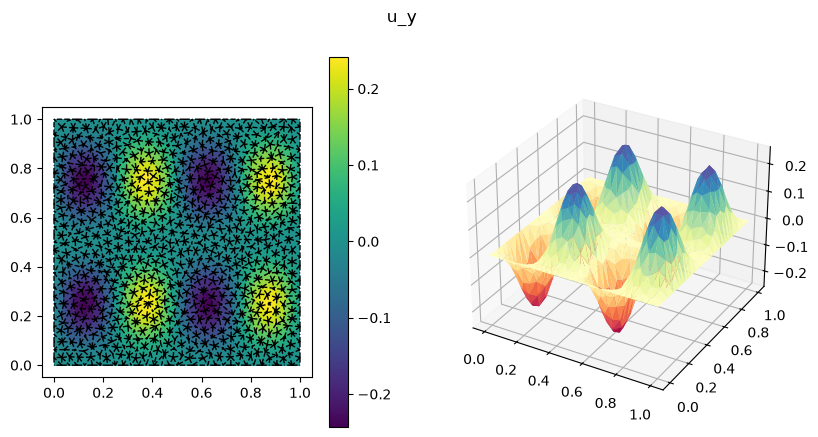

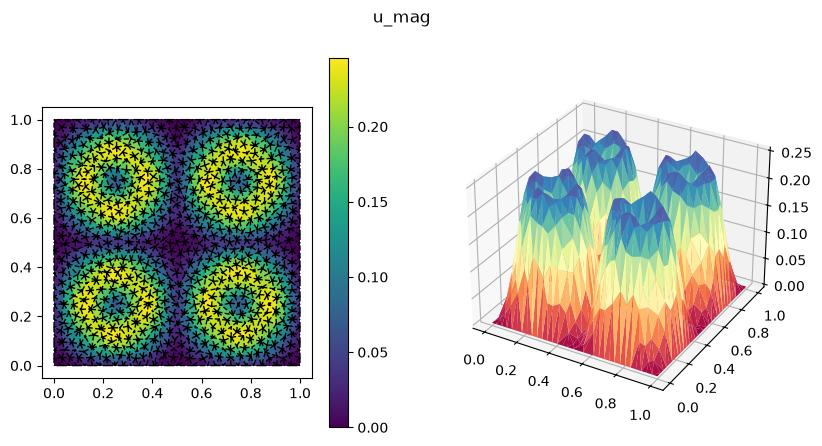

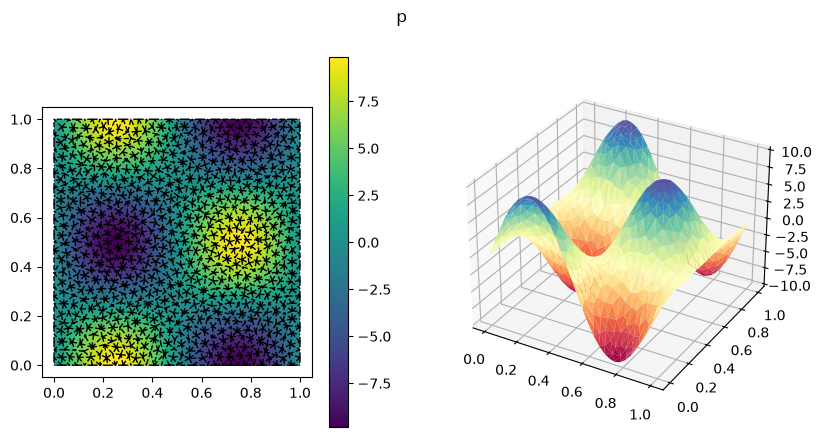

In [33]:
vtk_utilities.export_solution_2(export_solution_path + '/u_x',
                                mesh, 
                                u_x_on_cell0Ds.numeric_solution,
                                u_x_on_cell0Ds.exact_solution,
                                u_x_error_L2.cell2_ds_error_l2,
                               u_x_error_L2.cell2_ds_error_l2)
vtk_utilities.export_solution_2(export_solution_path + '/u_y',
                                mesh, 
                                u_y_on_cell0Ds.numeric_solution,
                                u_y_on_cell0Ds.exact_solution,
                                u_y_error_L2.cell2_ds_error_l2,
                               u_y_error_L2.cell2_ds_error_l2)
vtk_utilities.export_solution_2(export_solution_path + '/p',
                                mesh, 
                                p_on_cell0Ds.numeric_solution,
                                p_on_cell0Ds.exact_solution,
                                p_error_L2.cell2_ds_error_l2,
                               p_error_L2.cell2_ds_error_l2)
other_ut.plot_solution(mesh, u_x_on_cell0Ds.numeric_solution, "u_x") 
other_ut.plot_solution(mesh, u_y_on_cell0Ds.numeric_solution, "u_y")
other_ut.plot_solution(mesh, np.sqrt(u_x_on_cell0Ds.numeric_solution * u_x_on_cell0Ds.numeric_solution + u_y_on_cell0Ds.numeric_solution * u_y_on_cell0Ds.numeric_solution), "u_mag")
other_ut.plot_solution(mesh, p_on_cell0Ds.numeric_solution, "p") 